# 前期准备

In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


## 读取数据

In [3]:
infile = xr.open_dataset('E:/google/IBTrACS.WP.v04r01.nc')

In [3]:
stayyy=1949
endyyy=2024
censea=infile['season']
indsea=np.where((censea>=stayyy)&(censea<=endyyy))
numsea=censea[indsea]

In [4]:
tim=infile['time']
centim=tim.dt.month[:,0]
indtim=np.where((centim==7)|(centim==8)|(centim==9)|(centim==10))
numtim=tim[indtim]

In [5]:
centyp=infile['track_type']
indtyp=np.where(centyp==b'main')
numtyp=centyp[indtyp]

In [6]:
cenlat=infile['usa_lat']
nummia=np.sum(np.isnan(cenlat), axis=1)
numnma=np.sum(~np.isnan(cenlat), axis=1)  
minlat=np.amin(cenlat, axis=1)
minlat=np.amin(cenlat, axis=1)
indlat=np.where(numnma>=16)
numlat=cenlat[indlat]

In [7]:
cenlon=infile['usa_lon']
nummio=np.sum(np.isnan(cenlon), axis=1) 
numnmo=np.sum(~np.isnan(cenlon), axis=1)  
minlon=np.amin(cenlon, axis=1)  
maxlon=np.amax(cenlon, axis=1) 
indlon=np.where(numnmo>=16)
numlon=cenlon[indlon]

In [8]:
cenwin=infile['usa_wind']
nummiw=np.sum(np.isnan(cenwin), axis=1)   #每行nan个数
numnmw=np.sum(~np.isnan(cenwin), axis=1)  
maxwin = np.amax(cenwin, axis=1) 
indmaw = np.where(maxwin>=35) 
indwin = np.where((numnmw>=16)&(maxwin>=35))
numwin =cenwin[indwin]
# numwin

In [9]:
cenatu=infile['nature']
numnat= np.sum(np.isin(cenatu, [b'DS', b'ET']), axis=1)#有多少个DS,ET,要这俩=0的地方
numb=np.sum(cenatu != b'', axis=1)#非空值的个数，用于去除空值以及小于48小时的情况,numb>16,3h
indnat=np.where((numb!=numnat)&(numb>16))

In [10]:
lat = infile['usa_lat']

# 创建布尔掩码以筛选7、8、9月份的数据
mask = lat['time'].dt.month.isin([7, 8, 9])

# 保留掩码对应的数据并将其他数据设为NaN
lat2 = lat.where(mask, drop=True)

# 打印筛选后的数据以检查结果
# print(lat2)

## 登陆landindall_flat

In [11]:
cendis=infile['dist2land']
nummid=np.sum(np.isnan(cendis), axis=1)   
numnmd=np.sum(~np.isnan(cendis), axis=1)  #非nan数
num0md=np.sum(cendis==0, axis=1) #每行几个0
inddis=np.where((numnmd>=16)&(num0md>0))  #0代表登陆，看有几个0
numdis=cendis[inddis]#登录的结果
landindall=[]
landindallin=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16))
                    &((numnmd>=16)&(num0md>0)))
    landindall.append(indall[0])
landindall_flat = np.concatenate(landindall).tolist()  # 将所有数组拼接并转换为列表



## 副高

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# 加载数据
ds = xr.open_dataset('E:/data/era5.hgt.1980-2022.nc')
hgt = ds['z'] / 9.80665

# 按时间段选择数据
period1 = hgt.sel(time=slice('1982-01-01', '1997-12-31'))
period2 = hgt.sel(time=slice('1998-01-01', '2023-12-31'))
# period3 = hgt.sel(time=slice('2005-01-01', '2020-12-31'))

# 计算夏季(JJA)的平均高度
hgt1 = period1.sel(time=period1.time.dt.month.isin([7, 8, 9,10])).mean('time')
hgt2 = period2.sel(time=period2.time.dt.month.isin([7, 8, 9,10])).mean('time')



## 函数plot_change_data

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title,loc='left',fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

#     print(f"t-statistic: {t_stat}")
#     print(f"p-value: {p_value}")
    
    
    
#     x=years
#     y=data
#     #........................................................................................................   
    
#     # 计算线性回归
#     slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
#     # 计算 R 方
#     r_squared = r_value ** 2
#     ax = sns.regplot(x=x, y=y, ci=95,color='r')
# #     ax = sns.regplot(x=x, y=y, ci=95, color='r', scatter_kws={'s': 5}, line_kws={'linewidth': 1})
#     # 绘制散点图和回归线
#     plt.plot(x,y, alpha=1, linewidth=1.5,color='r')
# #     plt.plot(x, y, color='r', marker='o', linestyle='-', linewidth=1, markersize=5)

# #     plt.plot(x, intercept + slope * np.array(x), 'r')
#     print('R:',r_value)
#     print('P:', p_value)
#     print('R2:', r_squared)
    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
#     plt.text(1992, 1.05, f"Slope: {slope:.3f} ± {std_err:.3f}  per decade", fontsize=12, color='black')
    
    plt.show()
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, tomecur_totle, 'dist/km', 'Dist over Years', 17)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data_3(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title,loc='left',fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

#     print(f"t-statistic: {t_stat}")
#     print(f"p-value: {p_value}")
    
    
    plt.title(f't:{t_stat:.2f},p:{p_value:.3f}',loc='right',fontsize=12)
    
    plt.show()


# years = np.arange(1982, 2024)
# data = np.random.rand(40) * 100  # 示例数据
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, data, 'dist/km', 'Dist over Years', split_index)


In [5]:
years = np.arange(1982, 2024)
split_index=17

## 函数plot_type_tracks(df,title)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.mpl.ticker as cticker

def plot_type_tracks(df,title):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    
    
    
    id1=df['Typhoon ID']
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
#     plt.subplot(loc)
    ax.set_extent([100, 180, 0, 60])
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=False)
    # ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
    ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
    # ax.set_xticks([0,20,40,60]) # 设置刻度
    ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
    ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 'x-large') # 设置刻度标签
    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())


    for i in range(0,len(id1)):  
        indall = id1[i]
        lat = infile['usa_lat'][indall]  
        lon = infile['usa_lon'][indall]  
        arrlat= np.array([num for num in lat.values if not np.isnan(num)])
        arrlon= np.array([num for num in lon.values if not np.isnan(num)])
        ax.plot(arrlon, arrlat, color='orange', transform=ccrs.Geodetic(), linewidth=1.5)    
    plt.title(title,fontsize=15)
    print(len(id1),np.mean(df['Curvature']))
    plt.show()    


# df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
# plot_type_tracks(df,'title')

# 弯曲度变化

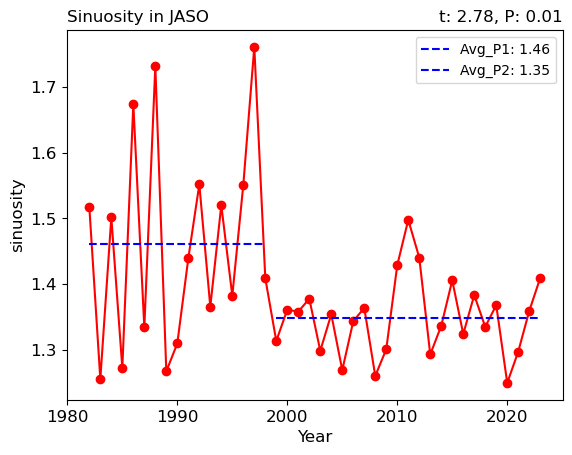

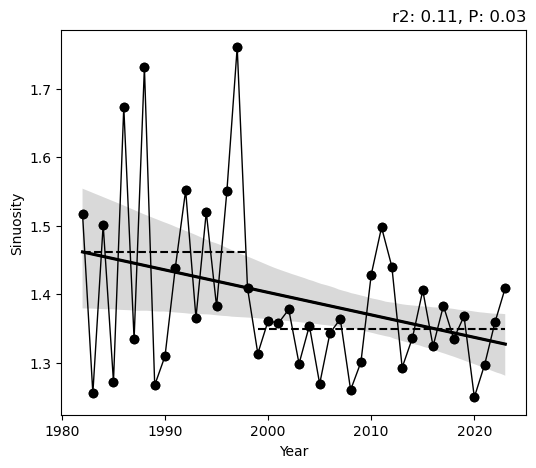

R: -0.328467967832936
P: 0.0336872372166253
R2: 0.1078912058922987


In [18]:
tomecur=[]
tonccur=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16)))
    numatc=np.array(indall).shape[1]#台风个数tonccur

   
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        orilat=arrlat[0]
        endlat=arrlat[-1]
        
        orilon=arrlon[0]
        endlon=arrlon[-1]
       
        ori=[orilat,orilon]#起点集合
        end=[endlat,endlon]
        dist=great_circle(ori, end).kilometers#起点和终点的距离
        if dist!=0:
        
            coor=np.column_stack((arrlat, arrlon))#合并经纬度
            todist=0#总距离todist
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k+1]).kilometers
                todist += distall
            cur=todist/dist#一个台风的曲率
#             if cur<4.96:
#             print(cur)
            tocur.append(cur)
        mecur=np.mean(tocur)#平均曲率
    tomecur.append(mecur)#40yr平均曲率
tomecur_totle=tomecur

plot_change_data(years,tomecur_totle, 'sinuosity', 'Sinuosity in JASO', 17)
# x=years
# y=tomecur_totle
# #........................................................................................................   
# fig, ax = plt.subplots(figsize=(6, 5))
# # 计算线性回归
# slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# # 计算 R 方
# r_squared = r_value ** 2
# ax = sns.regplot(x=x, y=y, ci=95,color='black')
# # 绘制散点图和回归线
# plt.plot(x,y,'k-o', alpha=1, linewidth=1)
# plt.plot(x, intercept + slope * np.array(x), 'black')
# plt.xlabel('Year')
# plt.ylabel('Sinuosity')
# plt.show()
# print('R:',r_value)
# print('P:', p_value)
# print('R2:', r_squared)


#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

# 起始点

## C3

1982-1998年平均纬度: 14.997109829345879, 经度: 148.3086705290513
1999-2023年平均纬度: 17.16541668375333, 经度: 145.8504165649414
纬度的t检验统计量: -3.680744369309635, p值: 0.00027128984500427876
经度的t检验统计量: 1.6213588909520704, p值: 0.10588679083654887


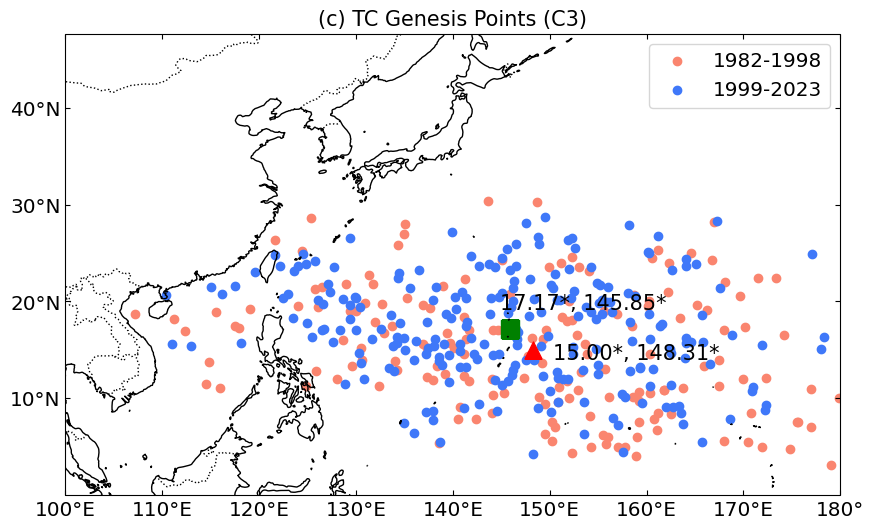

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

# 加载数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
df['toorilon'] = df['toorilon'].apply(lambda x: x + 360 if x < 0 else x)
id1 = df['Typhoon ID']
idyr = df['year']
oriloclat = df['toorilat']
oriloclon = df['toorilon']

# 分成两个时期的数据
df_period1 = df[(df['year'] >= 1982) & (df['year'] <= 1998)]
df_period2 = df[(df['year'] >= 1999) & (df['year'] <= 2023)]

# 计算两个时期的经纬度平均值
mean_lat_period1 = df_period1['toorilat'].mean()
mean_lon_period1 = df_period1['toorilon'].mean()

mean_lat_period2 = df_period2['toorilat'].mean()
mean_lon_period2 = df_period2['toorilon'].mean()

print(f"1982-1998年平均纬度: {mean_lat_period1}, 经度: {mean_lon_period1}")
print(f"1999-2023年平均纬度: {mean_lat_period2}, 经度: {mean_lon_period2}")

# 执行t检验，检验两个时期的台风起点纬度的显著性差异
t_stat_lat, p_value_lat = stats.ttest_ind(df_period1['toorilat'], df_period2['toorilat'], equal_var=False)
t_stat_lon, p_value_lon = stats.ttest_ind(df_period1['toorilon'], df_period2['toorilon'], equal_var=False)

print(f"纬度的t检验统计量: {t_stat_lat}, p值: {p_value_lat}")
print(f"经度的t检验统计量: {t_stat_lon}, p值: {p_value_lon}")

# 设置地图和特征
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, 0, 40])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 41, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(10, 41, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# 标记是否已添加图例
added_legend = {'1982-1998': False, '1999-2023': False}

# 绘制台风的起点，根据年份使用不同颜色
# Add indices of points you don't want to plot
skip_indices = [97, 111,123]

# Modify the plotting loop to skip these indices
for i in range(len(id1)):
    if i in skip_indices:
        continue  # Skip the plotting for these indices
    
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    # 选择颜色和标签
    if 1982 <= year <= 1998:
        color = '#fa856f'
        label = '1982-1998'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())
    
    elif 1999 <= year <= 2023:
        color =  '#3f78f9'
        label = '1999-2023'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())


# 添加图例
ax.legend(loc='upper right', fontsize='x-large')
# 在图中标出两个时期的平均值，并用三角形和正方形表示

# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=150, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 2, mean_lat_period1-1, f'{mean_lat_period1:.2f}*, {mean_lon_period1:.2f}*', fontsize=15, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='green', marker='s', s=150, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2-1 , mean_lat_period2+2, f'{mean_lat_period2:.2f}*, {mean_lon_period2:.2f}*', fontsize=15, transform=ccrs.Geodetic())

# 设置标题和显示图形
plt.title('(c) TC Genesis Points (C3)', fontsize=15)
plt.show()


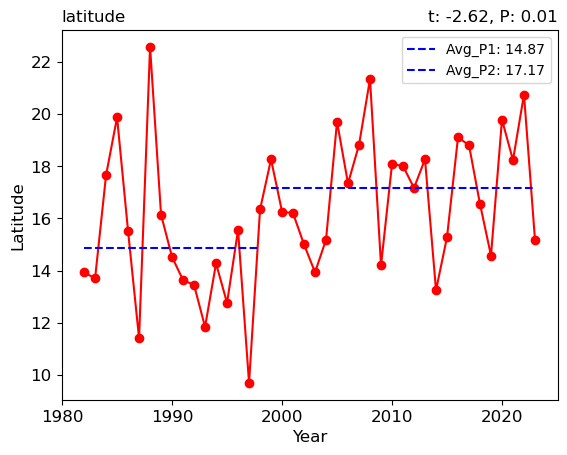

In [6]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
latoneyear=[]
for iyr in range(1982,2024):
    year_data = df[df['year'] == iyr]
    average_toorilat = year_data['toorilat'].mean()
    latoneyear.append(average_toorilat)
plot_change_data(years, latoneyear, 'Latitude', 'latitude', 17)

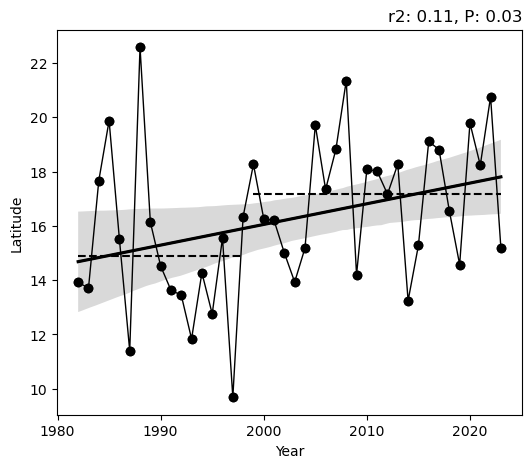

R: 0.3308215537015797
P: 0.03236053765027331
R2: 0.10944290039352716


In [8]:
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=latoneyear
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Latitude')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

In [57]:
np.mean(latoneyear[17:])

17.174081013171705

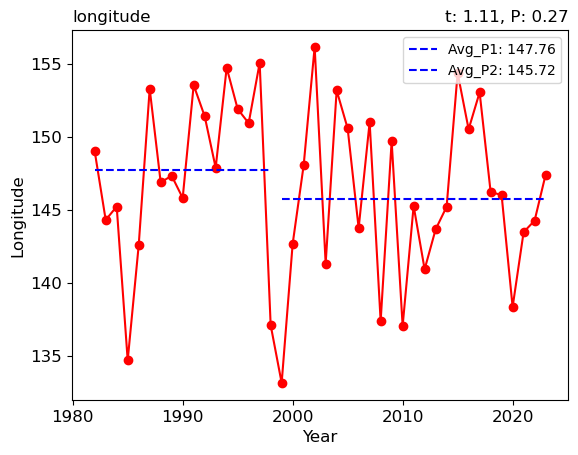

In [9]:
latoneyear=[]
for iyr in range(1982,2024):
    year_data = df[df['year'] == iyr]
    average_toorilat = year_data['toorilon'].mean()
    latoneyear.append(average_toorilat)
plot_change_data(years, latoneyear, 'Longitude', 'longitude', 17)

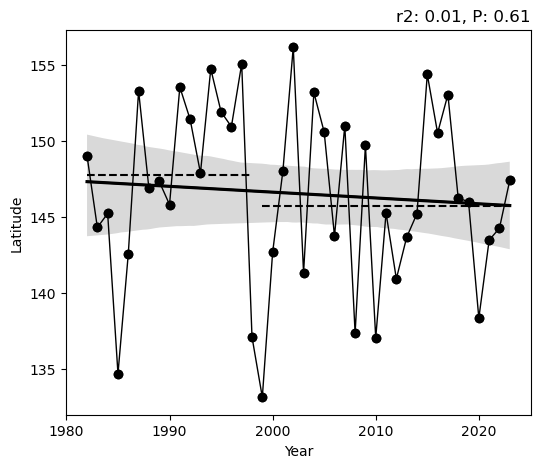

R: -0.08031285576463353
P: 0.6131394196864968
R2: 0.006450154801070828


In [10]:
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=latoneyear
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Latitude')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

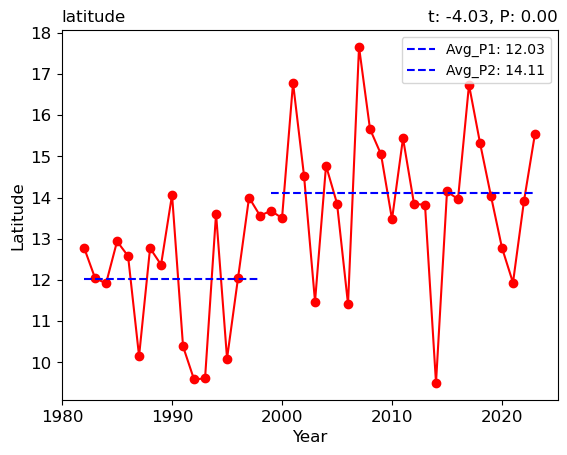

In [11]:
df = pd.read_excel(f'Typhoon_Cluster_2.xlsx')
latoneyear=[]
for iyr in range(1982,2024):
    year_data = df[df['year'] == iyr]
    average_toorilat = year_data['toorilat'].mean()
    latoneyear.append(average_toorilat)
plot_change_data(years, latoneyear, 'Latitude', 'latitude', 17)

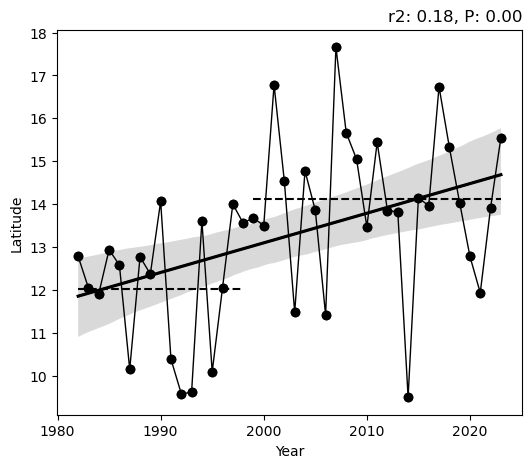

R: 0.4286288109518028
P: 0.004624055628786788
R2: 0.18372265757795628


In [12]:
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=latoneyear
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Latitude')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

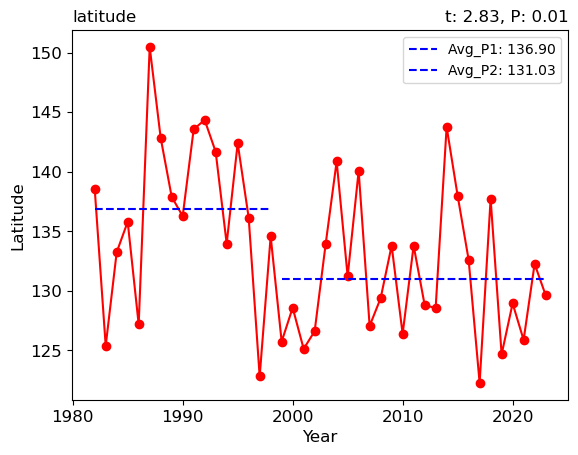

In [13]:
df = pd.read_excel(f'Typhoon_Cluster_2.xlsx')
latoneyear=[]
for iyr in range(1982,2024):
    year_data = df[df['year'] == iyr]
    average_toorilat = year_data['toorilon'].mean()
    latoneyear.append(average_toorilat)
plot_change_data(years, latoneyear, 'Latitude', 'latitude', 17)

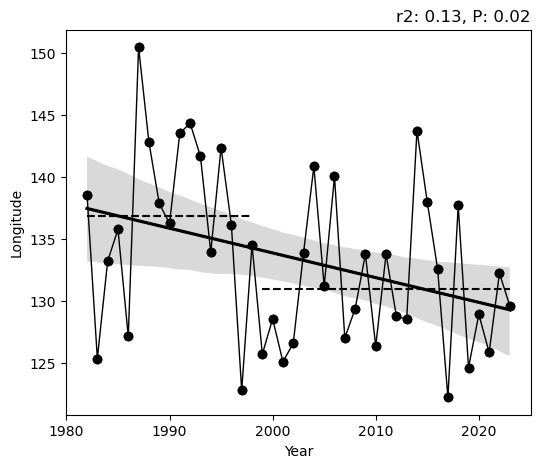

R: -0.35595704759693825
P: 0.020689666495934483
R2: 0.12670541973392896


In [15]:
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=latoneyear
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Longitude')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

# 结束点（没区别）

## C3

1982-1998年平均纬度: 37.40693650218104, 经度: 145.49248575199547
1999-2023年平均纬度: 37.725000047683714, 经度: 143.0174996058146
纬度的t检验统计量: -0.4761095142052461, p值: 0.634347185769365
经度的t检验统计量: 1.502225346541976, p值: 0.13399517656672444


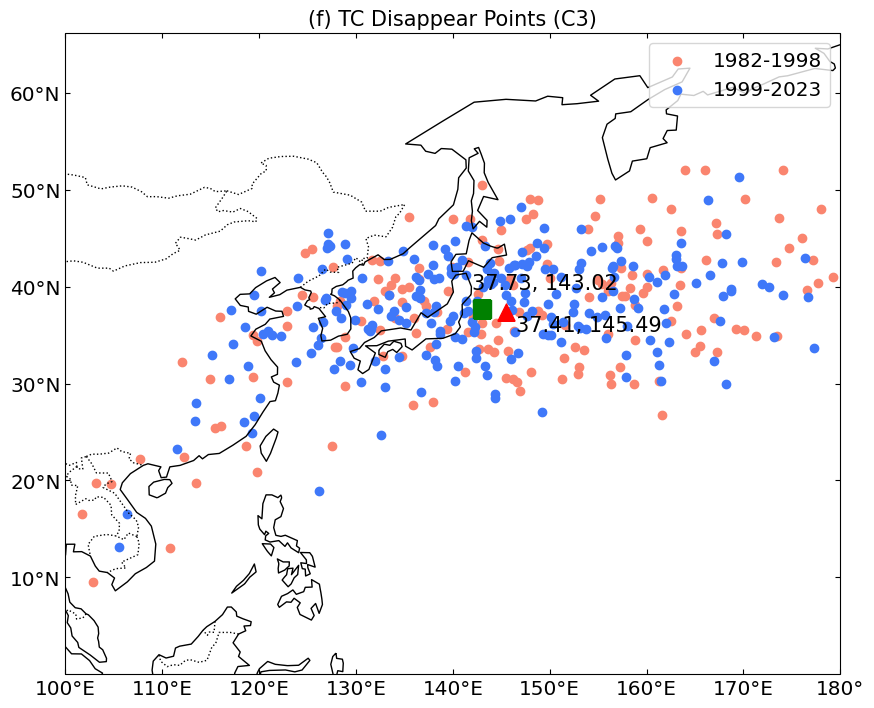

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

# 加载数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
id1 = df['Typhoon ID']
idyr = df['year']
oriloclat = df['toendlat']
oriloclon = df['toendlon']

# 分成两个时期的数据
df_period1 = df[(df['year'] >= 1982) & (df['year'] <= 1998)]
df_period2 = df[(df['year'] >= 1999) & (df['year'] <= 2023)]

# 计算两个时期的经纬度平均值
mean_lat_period1 = df_period1['toendlat'].mean()
mean_lon_period1 = df_period1['toendlon'].mean()

mean_lat_period2 = df_period2['toendlat'].mean()
mean_lon_period2 = df_period2['toendlon'].mean()

print(f"1982-1998年平均纬度: {mean_lat_period1}, 经度: {mean_lon_period1}")
print(f"1999-2023年平均纬度: {mean_lat_period2}, 经度: {mean_lon_period2}")

# 执行t检验，检验两个时期的台风起点纬度的显著性差异
t_stat_lat, p_value_lat = stats.ttest_ind(df_period1['toendlat'], df_period2['toendlat'], equal_var=False)
t_stat_lon, p_value_lon = stats.ttest_ind(df_period1['toendlon'], df_period2['toendlon'], equal_var=False)

print(f"纬度的t检验统计量: {t_stat_lat}, p值: {p_value_lat}")
print(f"经度的t检验统计量: {t_stat_lon}, p值: {p_value_lon}")

# 设置地图和特征
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, 0,60])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# 标记是否已添加图例
added_legend = {'1982-1998': False, '1999-2023': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    # 选择颜色和标签
    if 1982 <= year <= 1998:
        color = '#fa856f'
        label = '1982-1998'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())
    
    elif 1999 <= year <= 2023:
        color =  '#3f78f9'
        label = '1999-2023'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())

# 添加图例
ax.legend(loc='upper right',fontsize = 'x-large')
# 在图中标出两个时期的平均值，并用三角形和正方形表示

# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=150, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1-2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=15, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='g', marker='s', s=150, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2-1 , mean_lat_period2+2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=15, transform=ccrs.Geodetic())

# 设置标题和显示图形
plt.title('(f) TC Disappear Points (C3)',fontsize = 15)
plt.show()
